In [12]:
import os
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader,random_split

from model_tools import load_configs, add_config
from data_utils import SimulationData,generate_input_filename
from VAE import VAE, EmbeddedDataset, save_model, get_scheduler, reconstruct_z2fromz1

Modifica per caricare i dati di input e dare un nome al modello

In [13]:
tau = 15
embedding_dim = 20
alpha = 3
beta = 0
simulation_name= generate_input_filename(tau, embedding_dim, alpha, beta)
model_name = "Prima prova"
scheduler_name = "ReduceLROnPlateau"
print(simulation_name)

delay15dim20_noise3,0


In [14]:
# Percorso del database
model_database_path = "modelDatabase.json"

# Carica tutte le configurazioni disponibili
all_configs = load_configs(model_database_path)

print(model_name)

Prima prova


Modifica per cambiare la configurazione della rete: latent dim e layer (insieme), occhio agli input

In [ ]:
# Se vuoi creare una nuova configurazione
new_config = {
    "latent_dim": 4,
    "encoder_layers": [20,15,10,8,4],
    "decoder_layers": [4,10,15,20,25,30,35,40],
    "beta_method": "sigmoid",
    "beta_value": 0.5,
    "kl_annealing_epochs": 200,
    "early_stopping": {"patience": 10, "delta": 0.01}, # Early stopping -1 per disattivare
    "dataset": simulation_name,
    "batch_size": 32,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "scheduler": {
        "type": scheduler_name,  # Scheduler alternativo
        "params": {
            "mode": "min",  # Monitorare la perdita minima
            "factor": 0.1,
            "patience": 5
        }
    }
}

# Aggiungi la nuova configurazione al database
add_config(new_config, model_name, model_database_path)
print(all_configs)

{}


Modifica il NOME del modello da ALLENARE

In [16]:
# Carica una configurazione esistente
selected_model = new_config

# Carica i dati di simulazione
simulation = SimulationData.load_from_params(
    tau=tau, embedding_dim=embedding_dim, alpha=alpha, beta=beta, input_path="Simulation data"
)

# Seleziona gli embedding dal SimulationData
input_variable = "y1_embedding"  # Embedding di y1
output_variable1 = "y2_embedding_1"  # Embedding di y2_1
output_variable2 = "y2_embedding_2"  # Embedding di y2_2

# Recupera gli embedding da simulation
embedding_y1 = getattr(simulation, input_variable)
embedding_y2_1 = getattr(simulation, output_variable1)
embedding_y2_2 = getattr(simulation, output_variable2)

# Verifica che gli embedding siano stati generati correttamente
if embedding_y1 is None or embedding_y2_1 is None or embedding_y2_2 is None:
    raise ValueError("Uno o più embedding non sono stati generati correttamente!")

# Crea il dataset
embedded_dataset = EmbeddedDataset(embedding_y1, embedding_y2_1, embedding_y2_2)


print("y1_embedding shape:", simulation.y1_embedding.shape)  # Deve essere (n_samples, embedding_dim)
print(f"Dimensione embedding_y2_1: {embedding_y2_1.shape}")
print(f"Dimensione embedding_y2_2: {embedding_y2_2.shape}")


y1_embedding shape: (9715, 20)
Dimensione embedding_y2_1: (9715, 20)
Dimensione embedding_y2_2: (9715, 20)


In [17]:

# Suddivisione del dataset
total_size = len(embedding_y1)
train_size = int(0.60 * total_size)  # 60% per il training
val_size = total_size - train_size   # 40% per la validazione

# Suddivisione del dataset senza random split
train_data = torch.utils.data.Subset(embedded_dataset, range(train_size))
val_data = torch.utils.data.Subset(embedded_dataset, range(train_size, total_size))

# Stampa delle dimensioni
print(f"Dimensione del dataset: {total_size}")
print(f"Numero di campioni di training: {len(train_data)}")
print(f"Numero di campioni di validazione: {len(val_data)}")

# Prepara il DataLoader
batch_size = selected_model["batch_size"]
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Debug del batch
for batch in train_loader:
    x, y = batch  # Decomponi input e output
    x = x.float()
    y = y.float()
    print("Shape of input:", x.shape)
    break

Dimensione del dataset: 9715
Numero di campioni di training: 5829
Numero di campioni di validazione: 3886
Shape of input: torch.Size([32, 20])


Occhio al Learning rate: 0.1 e 0.01 causano instabilità numerica molto alte nei training, con conseguenti comportamenti anomali

Epoch [1/500], Rec Loss: 1.3486, KLD Loss: 0.1210, Beta: 0.0000, Training Loss: 1.3486
Epoch [2/500], Rec Loss: 1.2757, KLD Loss: 3.7262, Beta: 0.0001, Training Loss: 1.2759
Epoch [3/500], Rec Loss: 1.1472, KLD Loss: 12.7336, Beta: 0.0001, Training Loss: 1.1479
Epoch [4/500], Rec Loss: 1.1340, KLD Loss: 17.6954, Beta: 0.0001, Training Loss: 1.1351
Epoch [5/500], Rec Loss: 1.1288, KLD Loss: 20.7812, Beta: 0.0001, Training Loss: 1.1302
Epoch [6/500], Rec Loss: 1.1224, KLD Loss: 22.3923, Beta: 0.0001, Training Loss: 1.1240
Epoch [7/500], Rec Loss: 1.1132, KLD Loss: 23.4312, Beta: 0.0001, Training Loss: 1.1152
Epoch [8/500], Rec Loss: 1.0989, KLD Loss: 23.9363, Beta: 0.0001, Training Loss: 1.1011
Epoch [9/500], Rec Loss: 1.0784, KLD Loss: 25.1382, Beta: 0.0001, Training Loss: 1.0810
Epoch [10/500], Rec Loss: 1.0662, KLD Loss: 25.1718, Beta: 0.0001, Training Loss: 1.0690
Early stopping at epoch 11


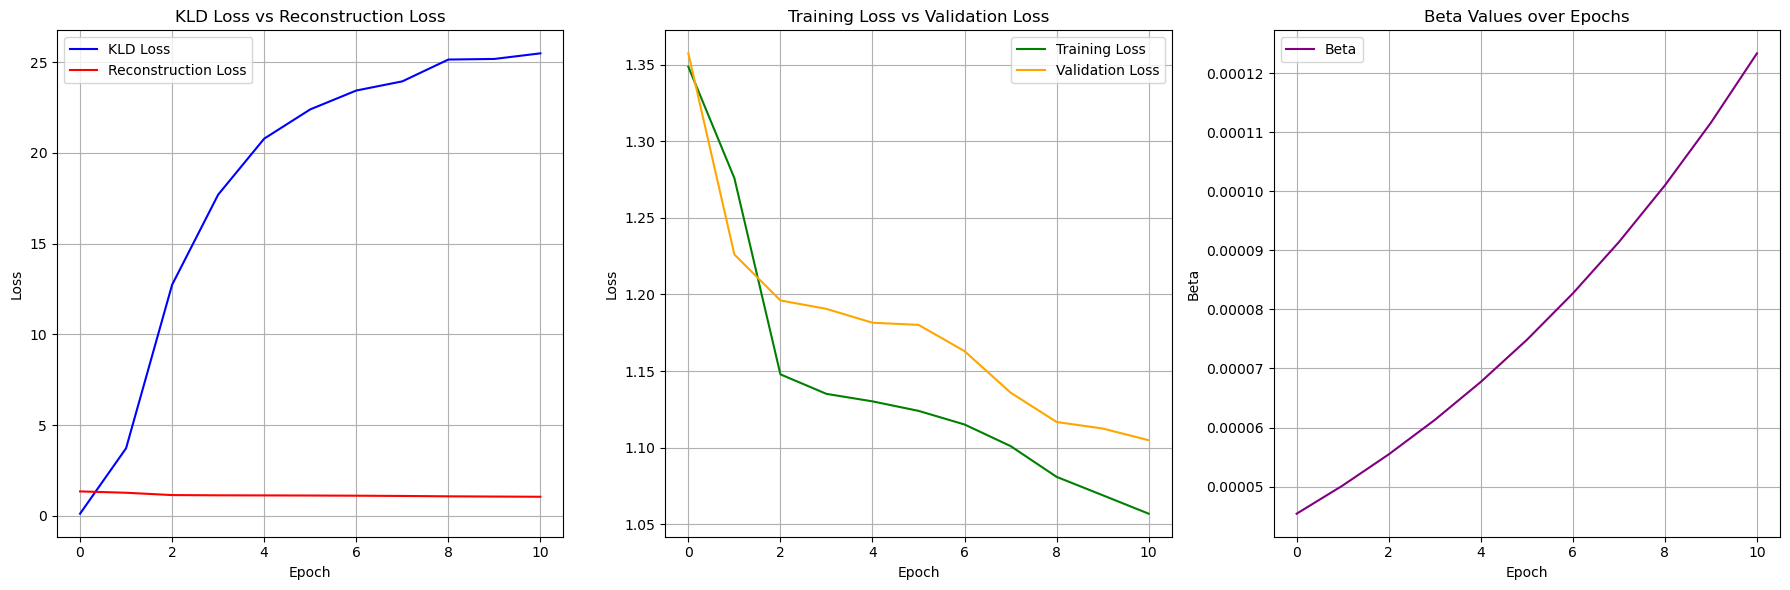

In [18]:
# Crea il modello
encoder_layers = selected_model["encoder_layers"]
decoder_layers = selected_model["decoder_layers"]
vae_model = VAE(encoder_layers,decoder_layers)

# Configura ottimizzatore e scheduler
optimizer = optim.Adam(vae_model.parameters(), lr=selected_model["learning_rate"])

# Configura lo scheduler
scheduler_config = selected_model.get("scheduler")
scheduler = get_scheduler(optimizer, scheduler_config)

# Allenamento del modello
train_losses, val_losses, recon_losses, kld_losses, beta_values, stopped_epoch = reconstruct_z2fromz1(
    epochs=500,
    train_loader=train_loader,
    val_loader=val_loader,  # Aggiungi se hai un dataset di validazione
    model=vae_model,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_config=scheduler_config,
    kl_annealing_epochs=selected_model["kl_annealing_epochs"],
    beta_method=selected_model["beta_method"],
    beta_value=selected_model["beta_value"],
    early_stopping_params=selected_model["early_stopping"]
)


In [19]:
def visualize_latent_space_with_pca(model, dataloader, device='cpu', n_components=2):
    model.eval()
    model.to(device)
    
    latent_mu = []
    true_labels = []

    # Estrazione dello spazio latente
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            _, mu, _ = model(inputs)  # Ottieni solo μ dallo spazio latente
            latent_mu.append(mu.cpu().numpy())
            true_labels.append(labels.cpu().numpy())

    # Concatena correttamente tutti i batch
    latent_mu = np.vstack(latent_mu)
    true_labels = np.concatenate(true_labels)[:len(latent_mu)]  # Allinea la dimensione a latent_mu

    # Applica la PCA per ridurre lo spazio latente
    pca = PCA(n_components=n_components)
    latent_pca = pca.fit_transform(latent_mu)

    # Visualizza il risultato
    if n_components == 2:
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(latent_pca[:, 0], latent_pca[:, 1], 
                               c=true_labels[:len(latent_pca)], cmap='viridis', s=10)
        plt.colorbar(scatter, label='Class Labels')
        plt.title('Latent Space Visualization with PCA (2D)')
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        plt.show()
    elif n_components == 3:
        from mpl_toolkits.mplot3d import Axes3D
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(latent_pca[:, 0], latent_pca[:, 1], latent_pca[:, 2],
                              c=true_labels[:len(latent_pca)], cmap='viridis', s=10)
        fig.colorbar(scatter, label='Class Labels')
        ax.set_title('Latent Space Visualization with PCA (3D)')
        ax.set_xlabel('Principal Component 1')
        ax.set_ylabel('Principal Component 2')
        ax.set_zlabel('Principal Component 3')
        plt.show()
    else:
        print(f"PCA visualization not supported for {n_components} dimensions.")

        


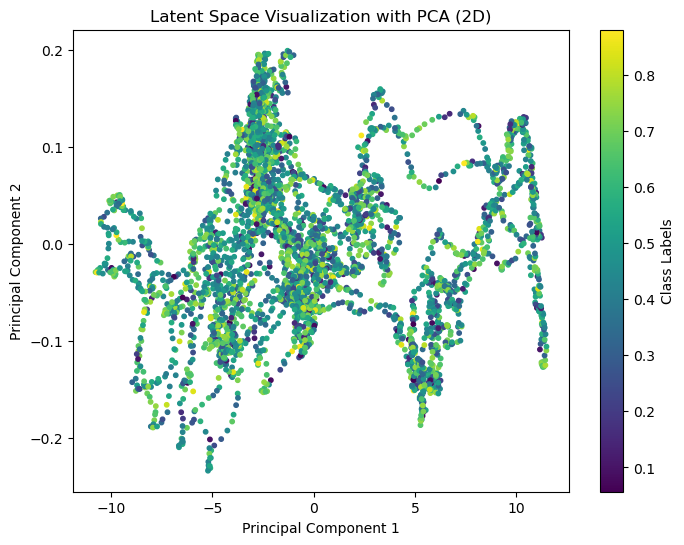

In [20]:
# Esegui la visualizzazione
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
visualize_latent_space_with_pca(vae_model, val_data, device=device, n_components=2)

In [21]:
# Carica la configurazione creata
all_configs = load_configs(model_database_path)

# Salva il modello
model_name += ".pth"
save_model(
    model=vae_model,
    optimizer=optimizer,
    train_data=train_data,
    val_data=val_data,  # Aggiungi se hai un dataset di validazione
    epoch=50,
    stopped_epoch=stopped_epoch,
    encoder_layers=selected_model["encoder_layers"],
    decoder_layers=selected_model["decoder_layers"],
    train_losses=train_losses,
    val_losses=val_losses,
    recon_losses=recon_losses,
    kld_losses=kld_losses,
    beta_values=beta_values,
    output_folder="Models",
    model_name=model_name
)


Model saved to Models\Prima prova.pth
